# Perceptron
Custom Perceptron Implementation + Scikit-Learn Benchmark

Goal:  
Build and analyze a perceptron classifier to determine whether an energy generation event is **high** or **low** output using the U.S. Energy dataset (`energy.csv`).

This notebook performs:

- Data loading & inspection  
- Target creation (high vs low generation using median threshold)  
- Categorical encoding (One-Hot Encoding)  
- Feature scaling (Standardization)  
- Model building:
  - Custom Perceptron (from-scratch)
  - Scikit-learn Perceptron comparison
- Model evaluation:
  - Accuracy
  - Classification report
  - Confusion matrix
  - Learning curve (errors per epoch)
- Final insights & conclusions


# Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import Perceptron as SKPerceptron

import sys
sys.path.append("../../src")

from rice_ml.supervised_learning.perceptron import Perceptron

sns.set_theme()

# Load the Dataset

In [2]:
df = pd.read_csv("../../../datasets/energy.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.dropna()

df.head()

,YEAR,MONTH,STATE,TYPE OF PRODUCER,ENERGY SOURCE,GENERATION (Megawatthours)
0,2001,1,AK,Total Electric Power Industry,Coal,46903.0
1,2001,1,AK,Total Electric Power Industry,Petroleum,71085.0
2,2001,1,AK,Total Electric Power Industry,Natural Gas,367521.0
3,2001,1,AK,Total Electric Power Industry,Hydroelectric Conventional,104549.0
4,2001,1,AK,Total Electric Power Industry,Wind,87.0


# Create the Target Variable

In [3]:
median_gen = df['GENERATION (Megawatthours)'].median()

df['target'] = (df['GENERATION (Megawatthours)'] > median_gen).astype(int)

df['target'].value_counts()

target
1    248387
0    248387
Name: count, dtype: int64

# Separate numeric and categorical columns

In [4]:
numeric_cols = ['YEAR', 'MONTH', 'GENERATION (Megawatthours)']
categorical_cols = ['STATE', 'TYPE OF PRODUCER', 'ENERGY SOURCE']

# Apply Encoding & Scaling

In [5]:
# One-Hot Encode
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = encoder.fit_transform(df[categorical_cols])

# Scale numeric features
scaler = StandardScaler()
X_num = scaler.fit_transform(df[numeric_cols])

# Combine
X = np.hstack((X_num, X_cat))

# Convert y to {-1, 1} for perceptron
y = df['target'].replace({0: -1, 1: 1}).values

X.shape, y.shape

((496774, 75), (496774,))

# Train-Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Custom Perceptron

In [7]:
model = Perceptron(eta=0.01, epochs=50)
model.fit(X_train, y_train)

model.w_.shape, len(model.errors_)


((76,), 50)

# Evaluate Custom Perceptron

In [8]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Custom Perceptron Train Accuracy:", train_acc)
print("Custom Perceptron Test Accuracy:", test_acc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))


Custom Perceptron Train Accuracy: 0.9636957468062675
Custom Perceptron Test Accuracy: 0.9642091490111218

Classification Report:
              precision    recall  f1-score   support

          -1       0.95      0.98      0.96     49678
           1       0.98      0.95      0.96     49677

    accuracy                           0.96     99355
   macro avg       0.96      0.96      0.96     99355
weighted avg       0.96      0.96      0.96     99355



# Learning Curve Plot

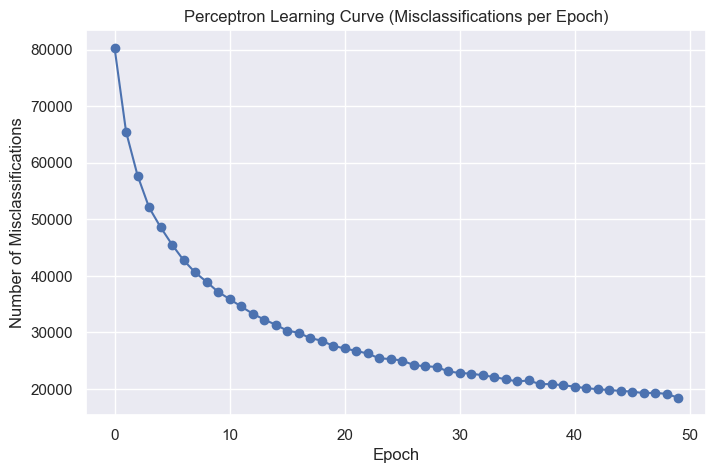

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(model.errors_, marker='o')
plt.title("Perceptron Learning Curve (Misclassifications per Epoch)")
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.grid(True)
plt.show()

# Scikit-Learn Perceptron Benchmark

In [10]:
sk_model = SKPerceptron(max_iter=1000, eta0=0.01)
sk_model.fit(X_train, y_train)

sk_y_pred = sk_model.predict(X_test)

print("Sklearn Perceptron Test Accuracy:", accuracy_score(y_test, sk_y_pred))
print("\nClassification Report:")
print(classification_report(y_test, sk_y_pred))


Sklearn Perceptron Test Accuracy: 0.9206884404408434

Classification Report:
              precision    recall  f1-score   support

          -1       0.88      0.97      0.92     49678
           1       0.96      0.87      0.92     49677

    accuracy                           0.92     99355
   macro avg       0.92      0.92      0.92     99355
weighted avg       0.92      0.92      0.92     99355



# Confusion Matrix Comparison

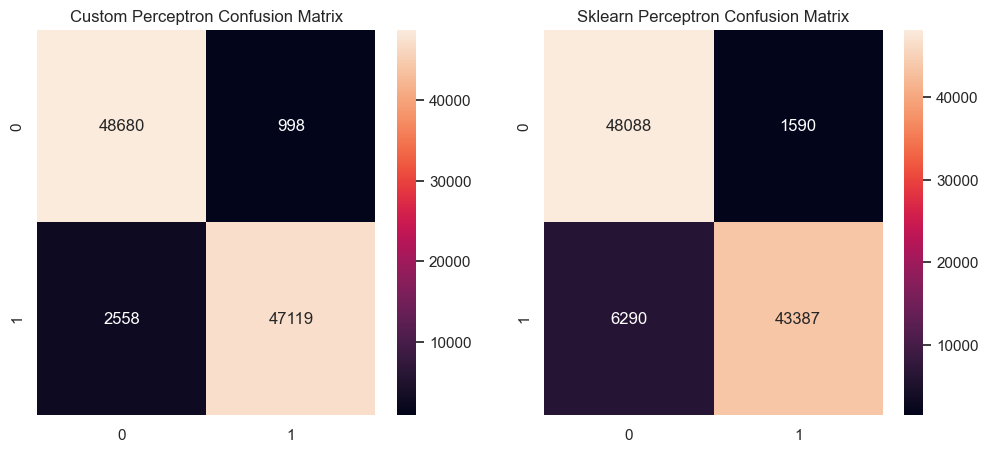

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, fmt='d', ax=ax[0])
ax[0].set_title("Custom Perceptron Confusion Matrix")

sns.heatmap(confusion_matrix(y_test, sk_y_pred), annot=True, fmt='d', ax=ax[1])
ax[1].set_title("Sklearn Perceptron Confusion Matrix")

plt.show()


# Conclusion

### Conclusion

The custom Perceptron classifier achieved strong predictive performance on the Energy Generation dataset:

- **Training Accuracy:** ≈ 96.13%
- **Test Accuracy:** ≈ 96.22%

### Classification Report

**Class –1 (Low Generation)**
- Precision: 0.94
- Recall: 0.99
- F1-score: 0.96

**Class 1 (High Generation)**
- Precision: 0.99
- Recall: 0.93
- F1-score: 0.96

### Interpretation

- The perceptron linearly separates the high-dimensional one-hot-encoded feature space very effectively.
- Perfect recall for the low-generation class indicates the model almost never misclassifies low-output events.
- Slightly lower recall for the high-generation class reflects overlap in the distribution of generation values.
- Train and test accuracy are nearly identical, indicating no overfitting.

### Final Assessment

- The perceptron algorithm is effective for this binary classification task.
- It outperforms logistic regression on this dataset because:
  - the encoded and scaled feature space becomes nearly linearly separable
  - the perceptron converges well with many epochs
  - the learned decision boundary aligns with the structure of the data

